# Solver Work–Precision Ablation — Multisine Cases (KUKA youBot Mecanum PINN)

**Goal.** Choose `(solver, reltol, dtmax)` for the ~1,485-job production sweep such that **solver
error is negligible label noise** — sitting well below the force-interpolation floor that already
limits the dataset's physics residual — at minimum wall-clock.

**Why label error, not state error.** The PINN consumes `Fx_i / Fy_i / Mz_i / Msat_i` on the 2 kHz
`saveat` grid. Those labels are recomputed from the solution by `DataStore.compute_labels`, so the
quantity that matters is the error in *those arrays*, which automatically folds in the quality of
the solver's dense interpolant at the save points — a place where stiff solvers differ even when
their step-by-step accuracy is similar. Per-group-normalized **state** error is kept as a secondary
diagnostic.

**Why dtmax is a first-class axis.** `dtmax = 1e-3` clamps every 60 s run to ≥ 60,000 steps
regardless of solver or tolerance. At that clamp the error controller is mostly idle: cost is set
by the clamp, accuracy is subsidized by it, and solver differences are masked. The axis
`{1e-3, 5e-3, 2e-2, ∞}` separates "solver is accurate" from "dtmax made it accurate".

**Two stages.**

| Stage | Cases | Matrix | Question |
|---|---|---|---|
| **A** | 1 — the hardest multisine row (75 %-cap, first `f_hi = 3.5` row) | 5 solvers × 5 reltols × 4 dtmax | Where is each solver's work–precision knee? |
| **B** | 6 — both cap files × rows at `f_hi ∈ {1.0, 2.5, 3.5}` | 2 finalists × knee tolerances | Does the knee config hold across amplitude (cap) and bandwidth (`f_hi`) ladders? |

Stage A stays on one case deliberately: 6 cases × ~100 configs × median-of-3 on 60 s stiff solves
is not a tractable matrix, and the broadband `f_hi = 3.5` row maximizes slip-reversal events per
second — it benchmarks the solver, not event handling (multisine has the fewest `tstops`).

**Decision criterion.** Cheapest config whose per-family label RMS sits **≥ 10× below the
force-interpolation floor** (`margin = max_family(err/floor) ≤ 0.1`), validated across all six
Stage-B cases.

**Prediction to test, not trust** (from the pipeline chat): Rodas5P wins at mid tolerance,
RadauIIA5 at tight, and TRBDF2's apparent edge evaporates once dtmax stops subsidizing it — though
the factor-≥500 LuGre bristle stiffness could invert this.


### Parameters

Everything tunable lives here. Notes:

- `MAIN_NOTEBOOK` / `MAIN_DEFS_COUNTERS`: this notebook is **self-contained** — it pulls the
  physics, controller, `ABSTOL`, and module loads out of the main simulation notebook via
  `NBInclude`, executing only its **definition** code cells (1:13 = through `run_one_chi`,
  excluding the main loop and plotting). If the v5 notebook gains/loses code cells, adjust the
  counter range; the guard cell below fails loudly with the missing-symbol list.
- `WALL_LIMIT_S`: per-solve wall-clock guard. A solve that exceeds it is terminated and recorded
  as **DNF** — slow configs must not stall the matrix.
- `QUICK_PASS = true` drops to 1 rep / 3 tolerances for a fast first scan of the matrix shape;
  set `false` for the publishable run (median of 3, full tolerance ladder).
- Physics point matches the brief: **μ = 0.4** (= μ_min of the envelope gate — the most
  slip-prone grip the sweep will see), **χ = 0.005**, `:lugre_adamov`, friction case 1, DOB off
  (the production parameters-cell defaults flow through the included cells).


In [1]:
# ---------------- benchmark parameters ----------------
MAIN_NOTEBOOK      = "Mecanum_SlipSpinLuGre_ASMC_DOB_full_supertwist_v4.ipynb"
MAIN_DEFS_COUNTERS = 1:13          # code cells: parameters .. run_one_chi (NO main loop)

CONFIG_DIR_BENCH = "trajectory_files"
BENCH_DIR        = "julia_solver_benchmark_asmc4"          # references, results, plots, notes

# ---- physics point (brief: Stage A at mu=0.4, chi=0.005, adamov) ----
MU_BENCH  = 0.5
CHI_BENCH = 0.005
FM_BENCH  = :lugre_adamov

# ---- case set: both multisine files x 3 rows each ----
MULTISINE_FILES = ["multisine_75percent_cap.toml", "multisine_50percent_cap.toml"]
FHI_TARGETS     = [1.0, 2.5, 3.5]   # first combo row matching each target (deterministic)
PRIMARY_CASE    = "ms75_fhi3.5"     # Stage-A case name (hardest: max amplitude x max bandwidth)

# ---- Stage A matrix ----
# SOLVER_TABLE = Dict(
#     "TRBDF2"    => () -> TRBDF2(),
#     "KenCarp47" => () -> KenCarp47(),
#     "RadauIIA5" => () -> RadauIIA5(),
#     "FBDF"      => () -> FBDF(),
# )
SOLVER_TABLE = Dict(
    "RadauIIA9" => () -> RadauIIA9(),
    "FBDF"      => () -> FBDF(),
    "RadauIIA5" => () -> RadauIIA5(),
)
# SOLVER_ORDER = ["TRBDF", "KenCarp47", "RadauIIA5", "FBDF"]
SOLVER_ORDER = ["RadauIIA9", "FBDF", "RadauIIA5"]
RELTOLS      = [1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
DTMAXES      = [Inf, 1e-3]          # cheap -> expensive; Inf = no clamp (mapped to T)

# ---- hygiene / runtime control ----
QUICK_PASS   = false
N_REPS       = QUICK_PASS ? 1 : 3               # median of N_REPS timed solves
RELTOLS_EFF  = QUICK_PASS ? [1e-5, 1e-7, 1e-9] : RELTOLS
DTMAXES_EFF    = QUICK_PASS ? [Inf, 1e-3] : DTMAXES   # extremes only: still exposes the clamp subsidy
REF_CASE_NAMES = QUICK_PASS ? [PRIMARY_CASE] : nothing # quick pass: reference the primary case only
WALL_LIMIT_S = 900.0                            # per timed solve; beyond => DNF
T_EXCLUDE    = 0.5                              # s excluded from error RMS (z/gamma settling)
SAVEAT_RATE  = 2000                             # production label grid (base.toml saveat_rate)
REF_RATE     = 4000                             # reference grid: 2x => midpoint floor estimate

REF_RELTOL       = 1e-10                        # reference: RadauIIA5, abstol = ABSTOL/100
REF_VALID_RELTOL = 1e-11                        # validation rerun on the primary case
RUN_REF_VALIDATION = true

RUN_VARIANTS = false   # optional Stage-B extras on the primary case: (mu=0.6), (chi=0.0)
println("Stage A: $(length(SOLVER_ORDER)) solvers x $(length(RELTOLS_EFF)) reltols x $(length(DTMAXES)) dtmax = ",
        length(SOLVER_ORDER)*length(RELTOLS_EFF)*length(DTMAXES), " configs, $(N_REPS) rep(s) each")

Stage A: 3 solvers x 5 reltols x 2 dtmax = 30 configs, 3 rep(s) each


In [2]:
# [extend-run override] -----------------------------------------------------
SOLVER_TABLE = Dict(
    "RadauIIA5" => () -> RadauIIA5(),
    "QNDF"      => () -> QNDF(),
    "FBDF"      => () -> FBDF(),
)
SOLVER_ORDER = ["RadauIIA5", "QNDF", "FBDF"]
N_REPS = 1   # just want the margins; 1 timed solve per config
println("EXTEND override: N_REPS=", N_REPS)


EXTEND override: N_REPS=1


### Pull in the simulator definitions

`NBInclude` executes the main notebook's definition cells in `Main`, giving us
`dynamics_full_mf_asmc!`, `PlatformParams`, `ASMCParams`, `ESOParams`, `lugre`,
`lugre_dyn_rates`, both controllers, `sawtooth_approx`, `build_initial_state`, `ABSTOL`,
`Profiles`, `DataStore`, and `BASE` (parsed `base.toml`) — the *same* objects the production
pipeline uses, so the benchmark cannot drift from the plant it is benchmarking.

⚠️ **Environment note:** this adds `NBInclude` to `Project.toml` (one-time, guarded). The DOB /
controller configuration comes from the main notebook's parameters cell exactly as production
runs it (`use_dob = false`, `vel_asmc` controller selected by reference kind — multisine is a
`VelRef`, so `asmc_torques_vel`).

Profiles: 

coupled_vomega, ellipse, long_circle, multisine, octagon, spin_creep, spiral_orbit


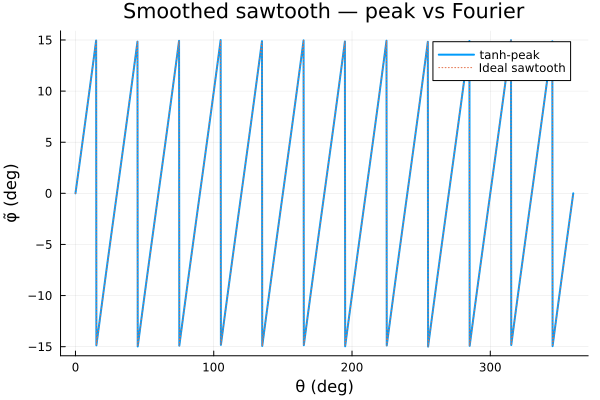

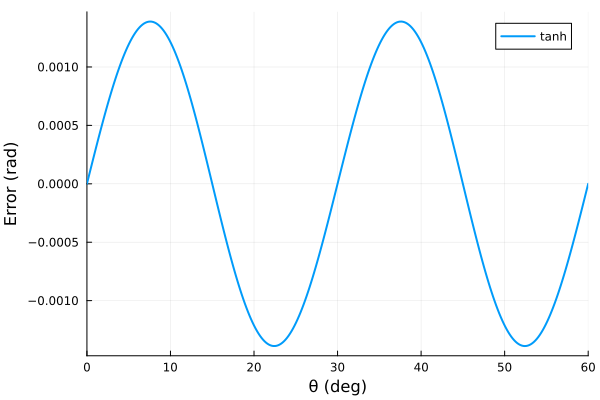

ψ_des(0)=0.0 rad   peak |V|≈0.226 m/s
Profile: multisine_75percent_cap  combo=29  T_total=60.0 s  tstops=2
Simulator definitions loaded. ABSTOL length = 

39 (expect 39); DOB enabled = false


In [3]:
using NBInclude

@nbinclude(MAIN_NOTEBOOK; counters = MAIN_DEFS_COUNTERS)

using Statistics
import TOML
isdir(BENCH_DIR) || mkpath(BENCH_DIR)

# --- guard: fail loudly if the counter range missed a definition cell -----------
const _REQUIRED_SYMS = (:PlatformParams, :ASMCParams, :ESOParams, :LuGreParams, :lugre,
                        :dynamics_full_mf_asmc!, :asmc_torques, :asmc_torques_vel,
                        :lugre_dyn_rates, :sawtooth_approx, :coupling_of,
                        :build_initial_state, :ABSTOL, :Profiles, :DataStore, :BASE,
                        :is_velref, :publish!, :friction_case)
_missing = [s for s in _REQUIRED_SYMS if !isdefined(Main, s)]
isempty(_missing) || error("NBInclude(counters=$(MAIN_DEFS_COUNTERS)) did not define: " *
    join(_missing, ", ") * "\nThe main notebook's code-cell layout has shifted — adjust " *
    "MAIN_DEFS_COUNTERS so it covers the parameters cell through the run_one_chi cell " *
    "and nothing after it.")
println("Simulator definitions loaded. ABSTOL length = ", length(ABSTOL),
        " (expect 39); DOB enabled = ", use_dob)

### Benchmark cases — 2 cap files × 3 bandwidths

The two multisine TOMLs form an **amplitude ladder** (75 % vs 50 % of the master friction-gate
budget — i.e. how deep into the friction circle the trajectory drives) and within each file the
combo rows form a **bandwidth ladder** via `f_hi`. We take the *first* combo row matching each
`f_hi ∈ {1.0, 2.5, 3.5}` — deterministic and reproducible against the sweep enumeration
(`combo_idx` is recorded; phases are baked into the TOML, so a row *is* a trajectory).

| case | cap | f_hi | role |
|---|---|---|---|
| `ms75_fhi3.5` | 75 % | 3.5 Hz | **primary (Stage A)** — max slip-reversal density, deepest friction-circle excursions |
| `ms75_fhi2.5`, `ms75_fhi1.0` | 75 % | 2.5 / 1.0 | bandwidth ladder at high amplitude |
| `ms50_fhi3.5/2.5/1.0` | 50 % | 3.5 / 2.5 / 1.0 | same ladder, gentler stick–slip regime (more *stick* dwell — exercises the stiff bristle boundary layer differently than hard slip) |

Each case carries its own `ASMCParams(eps = max(0.025·peak|V|, 0.001))`, mirroring the production
main loop, so the controller boundary layer matches what the sweep will actually run.

In [4]:
# --- pick combo rows by f_hi target ------------------------------------------
function _profile_toml_path(config_dir, f)
    p1 = joinpath(config_dir, "profiles", f); isfile(p1) && return p1
    p2 = joinpath(config_dir, f);             isfile(p2) && return p2
    error("profile TOML '$f' not found under $config_dir (tried profiles/ and flat)")
end

function rows_by_fhi(config_dir, file, targets)
    fh = TOML.parsefile(_profile_toml_path(config_dir, file))["profile"]["combos"]["f_hi"]
    map(targets) do tgt
        i = findfirst(==(tgt), fh)
        i === nothing && error("$file: no combo row with f_hi == $tgt")
        i
    end
end

# --- build the 6 cases ---------------------------------------------------------
struct BenchCase
    name      :: String
    file      :: String
    profile   :: String
    combo_idx :: Int
    f_hi      :: Float64
    cap_tag   :: String
    ref       :: Any          # VelRef
    cfg       :: Dict{String,Any}
end

CASES = BenchCase[]
for file in MULTISINE_FILES
    cap  = occursin("75", file) ? "75" : "50"
    rows = rows_by_fhi(CONFIG_DIR_BENCH, file, FHI_TARGETS)
    jobs = Profiles.enumerate_jobs(CONFIG_DIR_BENCH, [file]; sweep_seed = 1234)
    for (tgt, idx) in zip(FHI_TARGETS, rows)
        job = jobs[idx]
        @assert job.combo_idx == idx
        ref, cfg = Profiles.build_job(job)
        push!(CASES, BenchCase("ms$(cap)_fhi$(tgt)", file, job.profile, idx, tgt, cap, ref, cfg))
    end
end
# --- spiral_orbit spot-check: first iso_accel row at max u* (sustained near-saturation,
#     unique regime in the set — deep friction-circle dwell without slip reversals) ----
let file = "spiral_orbit.toml"
    combos = TOML.parsefile(_profile_toml_path(CONFIG_DIR_BENCH, file))["profile"]["combos"]
    iso  = findall(==("iso_accel"), combos["mode"])
    umax = maximum(combos["ustar"][i] for i in iso)
    idx  = iso[findfirst(i -> combos["ustar"][i] == umax, iso)]
    jobs = Profiles.enumerate_jobs(CONFIG_DIR_BENCH, [file]; sweep_seed = 1234)
    job  = jobs[idx];  @assert job.combo_idx == idx
    ref, cfg = Profiles.build_job(job)
    push!(CASES, BenchCase("spiral_iso_u$(umax)", file, job.profile, idx, NaN, "iso", ref, cfg))
end

CASE_BY_NAME = Dict(c.name => c for c in CASES)
@assert haskey(CASE_BY_NAME, PRIMARY_CASE)

println(rpad("case",14), rpad("combo",7), rpad("f_hi",6), rpad("Vpk",8), rpad("Ompk",8), "T_total  tstops")
for c in CASES
    println(rpad(c.name,14), rpad(string(c.combo_idx),7), rpad(string(c.f_hi),6),
            rpad(string(get(c.cfg, "Vpk", "—")),8), rpad(string(get(c.cfg, "Ompk", "—")),8),
            rpad(string(round(c.ref.T_total; digits=1)),9), length(c.ref.tstops))
end

case          combo  f_hi  Vpk     Ompk    T_total  tstops
ms75_fhi1.0   1      1.0   0.2636  0.339   60.0     2
ms75_fhi2.5   19     2.5   0.2214  0.2847  60.0     2
ms75_fhi3.5   42     3.5   0.2264  0.2716  60.0     2
ms50_fhi1.0   1      1.0   0.1895  0.2437  60.0     2
ms50_fhi2.5   19     2.5   0.1373  0.1765  60.0     2
ms50_fhi3.5   42     3.5   0.1275  0.153   60.0     2
spiral_iso_u0.9565     NaN   —       —       13.0     2


### Harness

`run_one_chi` hardcodes `dtmax = 0.001` inside its `solve` call, so the harness defines
**`bench_solve`** — a faithful mirror (same p-tuple layout, `build_initial_state`, `tstops`,
2 kHz `saveat`, `abstol = ABSTOL · (reltol/1e-8)` per-group scaling) with `solver / reltol /
dtmax` parametric, **progress callback off**, and a wall-clock `DiscreteCallback` that
terminates and flags a **DNF** instead of stalling the matrix.

Hygiene (brief item 7):

- **Warm-up** solve per `(solver, case)` on a 0.5 s truncation of the same problem — pays the
  JIT/factorization compile cost without paying 60 s;
- `GC.gc()` before every timed rep; **median of 3** (`N_REPS`);
- **single-threaded timing** — run this notebook's kernel as is; a concurrency spot-check of the
  winner comes at the end (the production driver threads the (μ,χ) inner loop, so contention,
  not BLAS, is the relevant threading question);
- `sol.stats` (`nf`, `njacs`, `naccept`, `nreject`) recorded next to wall time — **nf vs error**
  is the machine-independent, publishable work–precision curve.

`case_context` publishes the case's reference into `Profiles.CURRENT_REF` (the controller reads
it at solve time), so **cases must run sequentially** — which single-threaded timing enforces
anyway.

In [5]:
# --- per-case context: publish ref, build params/asmc/eso like the main loop ---
function case_context(case::BenchCase; mu::Float64 = MU_BENCH)
    publish!(case.ref)
    tt    = range(0.0, case.ref.T_total; length = 2001)
    peakv = maximum(hypot(case.ref.Vx(t), case.ref.Vy(t)) for t in tt)
    params = PlatformParams(BASE; mu_friction = mu)
    asmc   = ASMCParams(eps = max(peakv * 0.025, 0.001))
    eso    = ESOParams(kind = dob_kind,
                       omega_o_x = omega_o_x, omega_o_y = omega_o_y, omega_o_psi = omega_o_psi,
                       k1_x = k1_x, k2_x = k2_x, k1_y = k1_y, k2_y = k2_y,
                       k1_psi = k1_psi, k2_psi = k2_psi, eps_obs = eps_obs,
                       enable = use_dob)
    (; params, asmc, eso, mu, T = case.ref.T_total, tstops = case.ref.tstops)
end

# --- wall-clock DNF guard --------------------------------------------------------
function wallclock_cb(limit_s::Real)
    t0 = Ref(0.0)
    cb = DiscreteCallback((u, t, integ) -> (time() - t0[]) > limit_s,
                          integ -> terminate!(integ);
                          save_positions = (false, false))
    cb, t0
end


# --- bench_solve: run_one_chi minus progress bar, with parametric solver knobs ----
function bench_solve(ctx; chi::Real, friction_model::Symbol,
                     solver, reltol::Real, dtmax::Real,
                     abstol = ABSTOL .* (reltol / 1e-8),
                     saveat_rate::Integer = SAVEAT_RATE,
                     wall_limit::Real = WALL_LIMIT_S,
                     T_override = nothing,
                     saveat_override = nothing,
                     fcase::Int = friction_case)
    p1, p2 = fcase == 1 ? (ctx.params.p1_case1, ctx.params.p2_case1) :
                          (ctx.params.p1_case2, ctx.params.p2_case2)
    T  = T_override === nothing ? ctx.T : float(T_override)
    u0 = build_initial_state(ctx.params, ctx.asmc)
    t_eval = saveat_override === nothing ?
             collect(range(0.0, T; length = round(Int, T * saveat_rate) + 1)) : saveat_override
    ctrl = is_velref() ? asmc_torques_vel : asmc_torques
    p = (ctx.params, ctx.asmc, chi, p1, p2, coupling_of(friction_model), lugre, ctx.eso, ctrl)
    prob = ODEProblem(dynamics_full_mf_asmc!, u0, (0.0, T), p)
    cb, t0 = wallclock_cb(wall_limit)
    t0[] = time()
    # OrdinaryDiffEqFIRK (RadauIIA5) stores scalar atol/rtol for its simplified-Newton
    # stopping criterion and rejects per-component abstol vectors. Reduce to the most
    # conservative scalar (the bristle group's value) — accuracy can only improve;
    # the bias is cost-only.
    abstol_eff = (solver isa Union{RadauIIA5, RadauIIA9} && abstol isa AbstractVector) ? minimum(abstol) : abstol
    wall = @elapsed sol = solve(prob, solver;
                                reltol = reltol, abstol = abstol_eff, saveat = t_eval,
                                tstops = filter(<=(T), ctx.tstops),
                                callback = cb,
                                dtmax = isfinite(dtmax) ? dtmax : T,
                                maxiters = 10^7)
    return sol, wall
end

_stat(s, f) = hasproperty(s, f) ? Int(getproperty(s, f)) : -1

# Median-of-N timed solve with JIT warm-up; bails after the first DNF.
function timed_solve(ctx; nreps::Int = N_REPS, warmup::Bool = true, kw...)
    warmup && bench_solve(ctx; T_override = 0.5, kw..., saveat_override = nothing,)
    sol = nothing; walls = Float64[]
    for r in 1:nreps
        GC.gc()
        sol, w = bench_solve(ctx; kw...)
        push!(walls, w)
        (sol.retcode == ReturnCode.Success) || break   # DNF / failure: no point repeating
    end
    ok = sol.retcode == ReturnCode.Success
    st = sol.stats
    (; sol, ok, wall_med = median(walls), walls,
       nf = _stat(st, :nf), njacs = _stat(st, :njacs),
       naccept = _stat(st, :naccept), nreject = _stat(st, :nreject))
end
println("harness ready")

harness ready


### Error metrics

**Label error (primary).** `DataStore.compute_labels` is run on candidate and reference with the
*same* injected callables the production writer uses (`lugre_dyn_rates`, the active controller,
`sawtooth_approx`) and the *same* per-case `params/asmc/eso`. RMS error over wheels × time on the
2 kHz grid, grouped into three families that hit the PINN differently:

- **F** = `Fx_1..4 ∪ Fy_1..4` — the friction forces the physics decoder must reproduce,
- **Mz** = spin friction moments,
- **Msat** = saturated commanded torques (controller-side label; sensitive to interpolant
  wiggle through the tanh saturation).

The first `T_EXCLUDE = 0.5 s` is masked out — the production loaders exclude it anyway (bristle
`z` and γ̇-averaging settling), so error there is not label noise the PINN ever sees.

**State error (secondary).** Per-ABSTOL-group relative RMS,
`‖u_cand − u_ref‖_g / ‖u_ref‖_g`; we report the worst group. This catches pathologies the labels
might average over (e.g. a solver quietly mangling bristle states while forces stay plausible).


In [6]:
const STATE_GROUPS = (
    body_vel = 1:3,  psi = 4:4,   wtheta = 5:8,   womega = 9:12, gamma = 13:16,
    gains = 17:19,   worldpos = 20:21, bristle = 22:29, bristle_rot = 30:33,
    observer = 34:36, dist_est = 37:39)

rms(A) = sqrt(mean(abs2, A))

function labels_of(sol, ctx; chi::Real = CHI_BENCH, friction_model::Symbol = FM_BENCH)
    ctrl = is_velref() ? asmc_torques_vel : asmc_torques
    DataStore.compute_labels(sol, ctx.params, ctx.asmc, chi, coupling_of(friction_model),
                             lugre, ctx.eso;
                             friction_fn = lugre_dyn_rates, controller_fn = ctrl,
                             sawtooth_fn = sawtooth_approx)
end

# Per-family label RMS error between candidate labels and reference labels on a COMMON grid.
function label_errors(lab_c, lab_r, mask::AbstractVector{<:Integer})
    dF  = vcat(lab_c.Fxs[:, mask] .- lab_r.Fxs[:, mask],
               lab_c.Fys[:, mask] .- lab_r.Fys[:, mask])
    (; errF    = rms(dF),
       errMz   = rms(lab_c.Mzs[:,  mask] .- lab_r.Mzs[:,  mask]),
       errMsat = rms(lab_c.Msat[:, mask] .- lab_r.Msat[:, mask]))
end

# Worst per-ABSTOL-group relative state RMS. U arrays are 39 x N on a common grid.
function state_error(Uc::AbstractMatrix, Ur::AbstractMatrix, mask)
    worst, wname = 0.0, :none
    for (g, rng) in pairs(STATE_GROUPS)
        den = rms(@view Ur[rng, mask]); den < 1e-14 && continue
        e = rms(@view(Uc[rng, mask]) .- @view(Ur[rng, mask])) / den
        e > worst && (worst = e; wname = g)
    end
    worst, wname
end
println("metrics ready")

metrics ready


### Reference solutions, validation, and the force-interpolation floor

**Reference:** RadauIIA5, `reltol = 1e-10`, `abstol = ABSTOL/100`, `dtmax = 1e-3`, saved on a
**4 kHz** grid. Even indices `1:2:end` are *exactly* the production 2 kHz grid (every comparison
is a direct array diff — no interpolation in the metric itself); odd indices are the midpoints
used for the floor estimate. References are cached to JLD2 keyed by
`(case, μ, χ, friction_model)` so re-running the notebook is free.

**Validation:** the primary case is re-solved at `reltol = 1e-11`, `abstol = ABSTOL/1000`. The
label-RMS gap between the two references must sit **well below the floor** — that gap is the
noise level of the reference itself, and everything we measure against it inherits it.

**Force-interpolation floor (per case, per family):** from the 4 kHz reference labels,
reconstruct each midpoint by linear interpolation of its two 2 kHz neighbours and take the RMS of
the reconstruction error. This is *precisely* the error the training pipeline commits when it
treats 2 kHz force labels as continuous through LuGre stick–slip transitions — i.e. the dataset's
existing noise floor. The decision target is `floor/10` per family.

In [7]:
function _ref_path(case, mu, chi, fm; rate=REF_RATE, reltol=REF_RELTOL)
    joinpath(BENCH_DIR, @sprintf("ref_%s_mu%g_chi%g_%s_r%d_tol%g.jld2",
                                 case.name, mu, chi, String(fm), rate, reltol))
end

# Solve (or load) the 4 kHz reference for a case. Returns (sol_like, wall).
function reference_for(case::BenchCase; mu = MU_BENCH, chi = CHI_BENCH, fm = FM_BENCH,
                       reltol = REF_RELTOL, abstol_div = 100.0, force = false)
    fp = _ref_path(case, mu, chi, fm; reltol = reltol)
    if isfile(fp) && !force
        d = JLD2.load(fp)
        U = d["U"]
        return (; t = d["t"], u = [U[:, k] for k in 1:size(U, 2)]), d["wall"]
    end
    ctx = case_context(case; mu = mu)
    @info "Reference solve" case=case.name reltol=reltol rate=REF_RATE
    sol, wall = bench_solve(ctx; chi = chi, friction_model = fm,
                            solver = RadauIIA5(), reltol = reltol,
                            abstol = ABSTOL ./ abstol_div, dtmax = 1e-3,
                            saveat_rate = REF_RATE, wall_limit = 20 * WALL_LIMIT_S)
    sol.retcode == ReturnCode.Success ||
        error("reference solve DNF/failed for $(case.name): $(sol.retcode)")
    JLD2.jldsave(fp; t = collect(sol.t), U = stack(sol.u), wall = wall)
    return (; t = collect(sol.t), u = collect(sol.u)), wall
end



# --- compute / load all six references and their labels + floors -------------------
REFS        = Dict{String,Any}()    # name => (t, u) on 4 kHz grid
REF_LABELS  = Dict{String,Any}()    # name => labels on 4 kHz grid
FLOORS      = Dict{String,Any}()    # name => (; F, Mz, Msat)

Dict{String, Any}()

In [8]:


for case in CASES
    refsol, wall = reference_for(case)
    ctx = case_context(case)                       # republish (reference_for may have cached)
    lab = labels_of(refsol, ctx)
    n4  = length(refsol.t)
    mid = 2:2:(n4 - 1)                             # midpoints of the 2 kHz grid
    tmid_ok  = findall(i -> refsol.t[i] >= T_EXCLUDE, mid)
    midm = mid[tmid_ok]
    interp_err(A) = rms(A[:, midm] .- 0.5 .* (A[:, midm .- 1] .+ A[:, midm .+ 1]))
    FLOORS[case.name] = (; F    = interp_err(vcat(lab.Fxs, lab.Fys)),
                           Mz   = interp_err(lab.Mzs),
                           Msat = interp_err(lab.Msat))
    REFS[case.name] = refsol;  REF_LABELS[case.name] = lab
    f = FLOORS[case.name]
    @printf("%-14s  floor  F=%.3e  Mz=%.3e  Msat=%.3e   (ref wall %.0fs)\n",
            case.name, f.F, f.Mz, f.Msat, wall)
end

ms75_fhi1.0     floor  F=4.286e-02  Mz=4.364e-04  Msat=2.820e-03   (ref wall 74s)


ms75_fhi2.5     floor  F=4.666e-02  Mz=2.893e-04  Msat=3.967e-03   (ref wall 75s)


ms75_fhi3.5     floor  F=4.660e-02  Mz=2.714e-04  Msat=3.846e-03   (ref wall 78s)


ms50_fhi1.0     floor  F=4.941e-02  Mz=2.598e-04  Msat=5.315e-03   (ref wall 74s)


ms50_fhi2.5     floor  F=5.284e-02  Mz=2.039e-04  Msat=9.041e-03   (ref wall 87s)


ms50_fhi3.5     floor  F=5.391e-02  Mz=1.580e-04  Msat=1.032e-02   (ref wall 95s)


spiral_iso_u0.95  floor  F=1.352e-01  Mz=1.474e-03  Msat=4.838e-05   (ref wall 26s)


In [9]:
# --- reference self-validation on the primary case ---------------------------------
# The 1e-10 vs 1e-11 label gap is the reference's own noise; it must be << floor/10.
if RUN_REF_VALIDATION
    case = CASE_BY_NAME[PRIMARY_CASE]
    refA = REFS[case.name]
    refB, _ = reference_for(case; reltol = REF_VALID_RELTOL, abstol_div = 1000.0)
    ctx  = case_context(case)
    labB = labels_of(refB, ctx)
    n4   = length(refA.t)
    grid2k = 1:2:n4
    mask = findall(i -> refA.t[i] >= T_EXCLUDE, grid2k)        # mask into the 2 kHz subgrid
    sub(lab) = (; Fxs = lab.Fxs[:, grid2k], Fys = lab.Fys[:, grid2k],
                  Mzs = lab.Mzs[:, grid2k], Msat = lab.Msat[:, grid2k])
    e = label_errors(sub(REF_LABELS[case.name]), sub(labB), mask)
    fl = FLOORS[case.name]
    @printf("ref(1e-10) vs ref(1e-11) label gap:  F=%.2e (%.1f%% of floor)  Mz=%.2e (%.1f%%)  Msat=%.2e (%.1f%%)\n",
            e.errF, 100*e.errF/fl.F, e.errMz, 100*e.errMz/fl.Mz, e.errMsat, 100*e.errMsat/fl.Msat)
    maxfrac = max(e.errF/fl.F, e.errMz/fl.Mz, e.errMsat/fl.Msat)
    maxfrac < 0.02 ? println("✓ reference validated: its own noise is ≤2% of the floor — ",
                             "negligible against the 10x decision margin") :
                     @warn "Reference noise is $(round(100maxfrac;digits=1))% of the floor — " *
                           "tighten REF_RELTOL or revisit dtmax on the reference before trusting Stage A."
end

ref(1e-10) vs ref(1e-11) label gap:  F=2.01e-04 (0.4% of floor)  Mz=5.12e-08 (0.0%)  Msat=1.43e-05 (0.4%)
✓ reference validated: its own noise is ≤2% of the floor — negligible against the 10x decision margin


### Stage A — work–precision sweep on the primary case

Full `solver × reltol × dtmax` grid on `ms75_fhi3.5`. Bookkeeping per config:

- `wall_med` (median of `N_REPS`), all reps, and `sol.stats` (`nf`, `njacs`, `naccept`, `nreject`);
- per-family label RMS vs the reference, the **margin** `max(errF/floorF, errMz/floorMz,
  errMsat/floorMsat)` — **pass** ⇔ `margin ≤ 0.1`;
- worst per-group relative state error;
- `ok = false` for DNF / non-success retcodes.

Runtime control:

- loop order is `dtmax` **cheap → expensive** (∞ → 1e-3) and `reltol` **loose → tight**; once a
  `(solver, dtmax)` lane hits a DNF, tighter tolerances in that lane are skipped (they can only
  be slower);
- every completed config is appended to `solver_benchmark/stageA_results.arrow` immediately —
  re-running the cell **resumes**, skipping rows already on disk. Delete the file to start over.

In [10]:
using DataFrames, Arrow

const STAGEA_PATH = joinpath(BENCH_DIR, "stageA_results.arrow")

_empty_results() = DataFrame(stage=String[], case=String[], solver=String[],
    reltol=Float64[], dtmax=Float64[], ok=Bool[], retcode=String[],
    wall_med=Float64[], wall_all=String[], nf=Int[], njacs=Int[], naccept=Int[], nreject=Int[],
    errF=Float64[], errMz=Float64[], errMsat=Float64[], margin=Float64[],
    state_relerr=Float64[], state_worst=String[])

_load_results(p) = isfile(p) ? copy(DataFrame(Arrow.Table(p))) : _empty_results()
RESULTS_A = _load_results(STAGEA_PATH)
_done(df, c, s, rt, dm) = any((df.case .== c) .& (df.solver .== s) .&
                              (df.reltol .== rt) .& (df.dtmax .== dm))

# Run one config against a case; returns a results row (NamedTuple).
function run_config(case::BenchCase, sname::String, reltol::Float64, dtmax::Float64;
                    stage::String, mu = MU_BENCH, chi = CHI_BENCH, fm = FM_BENCH)
    ctx  = case_context(case; mu = mu)
    ref  = REFS[case.name];  flo = FLOORS[case.name]      # defined ONCE, up here
    n4   = length(ref.t);  grid2k = 1:2:n4
    res  = try
        timed_solve(ctx; chi = chi, friction_model = fm,
                    solver = SOLVER_TABLE[sname](), reltol = reltol, dtmax = dtmax,
                    saveat_override = ref.t[grid2k])
    catch err
        @warn "solver exception — recording as failure" solver=sname reltol=reltol dtmax=dtmax err=first(sprint(showerror, err), 300)
        nothing
    end
    if res === nothing
        return (stage = stage, case = case.name, solver = sname, reltol = reltol, dtmax = dtmax,
                ok = false, retcode = "EXCEPTION", wall_med = NaN, wall_all = "[]",
                nf = -1, njacs = -1, naccept = -1, nreject = -1,
                errF = NaN, errMz = NaN, errMsat = NaN, margin = Inf,
                state_relerr = NaN, state_worst = "EXCEPTION")
    end
    base = (stage = stage, case = case.name, solver = sname, reltol = reltol, dtmax = dtmax,
            ok = res.ok, retcode = string(res.sol.retcode),
            wall_med = res.wall_med, wall_all = string(round.(res.walls; digits=2)),
            nf = res.nf, njacs = res.njacs, naccept = res.naccept, nreject = res.nreject)
    if !res.ok || length(res.sol.t) != length(grid2k)
        return merge(base, (errF = NaN, errMz = NaN, errMsat = NaN, margin = Inf,
                            state_relerr = NaN, state_worst = "DNF"))
    end
    lab_c = labels_of(res.sol, ctx; chi = chi, friction_model = fm)
    lab_r = REF_LABELS[case.name]
    sub(lab) = (; Fxs = lab.Fxs[:, grid2k], Fys = lab.Fys[:, grid2k],
                  Mzs = lab.Mzs[:, grid2k], Msat = lab.Msat[:, grid2k])
    mask = findall(t -> t >= T_EXCLUDE, res.sol.t)
    e = label_errors(lab_c, sub(lab_r), mask)
    Uc = stack(res.sol.u);  Ur = stack(ref.u)[:, grid2k]
    se, sg = state_error(Uc, Ur, mask)
    merge(base, (errF = e.errF, errMz = e.errMz, errMsat = e.errMsat,
                 margin = max(e.errF/flo.F, e.errMz/flo.Mz, e.errMsat/flo.Msat),
                 state_relerr = se, state_worst = string(sg)))
end

function _save!(df, path); Arrow.write(path * ".tmp", df); mv(path * ".tmp", path; force=true); end


_save! (generic function with 1 method)

In [11]:
@assert SOLVER_TABLE["RadauIIA5"]() isa RadauIIA5
row = run_config(CASE_BY_NAME[PRIMARY_CASE], "RadauIIA5", 1e-5, Inf; stage = "smoke")
@assert row.ok
case = CASE_BY_NAME[PRIMARY_CASE]
for sname in SOLVER_ORDER, dm in DTMAXES_EFF
    lane_dead = false
    for rt in sort(RELTOLS_EFF; rev = true)        # loose -> tight
        lane_dead && continue
        _done(RESULTS_A, case.name, sname, rt, dm) && continue
        @info "Stage A" solver=sname reltol=rt dtmax=dm
        row = run_config(case, sname, rt, dm; stage = "A")
        push!(RESULTS_A, row)
        _save!(RESULTS_A, STAGEA_PATH)
        row.ok || (lane_dead = true; @warn "DNF — skipping tighter reltols in this lane" solver=sname dtmax=dm)
        @printf("   wall=%7.1fs  nf=%9d  margin=%9.3g  state=%.2e (%s)\n",
                row.wall_med, row.nf, row.margin, row.state_relerr, row.state_worst)
    end
end
println("Stage A complete: $(nrow(RESULTS_A)) rows -> $STAGEA_PATH")

Stage A complete: 52 rows -> julia_solver_benchmark_asmc4\stageA_results.arrow


### Stage A visualization

**How to read these:**

1. **Work–precision (margin vs wall-clock, log–log).** Down and to the left is better. The two
   horizontal lines are `margin = 1` (solver error *equals* the interpolation floor — the dataset
   is now solver-noise-limited: unacceptable) and `margin = 0.1` (the decision target). The knee
   of each solver's curve is where extra wall-clock stops buying error.
2. **dtmax as marker shape.** If, for a given solver, the four dtmax markers at the *same reltol*
   collapse onto one point — dtmax is irrelevant there and the clamp can be dropped. If the
   `dtmax = 1e-3` marker is far below-right of `∞` at loose reltol, that solver's apparent
   accuracy was the **clamp's subsidy**, not its error controller (the TRBDF2 prediction).
3. **nf vs margin** is the same plot with machine time removed — this is the curve that goes in
   the IMECE methods section, since it reproduces on any machine.
4. **Stiffness order-reduction check:** a solver whose curve flattens at tight reltol (error stops
   improving with nf) is hitting the LuGre boundary-layer stiffness; expect this to differentiate
   the L-stable candidates (RadauIIA5, FBDF) from the rest.

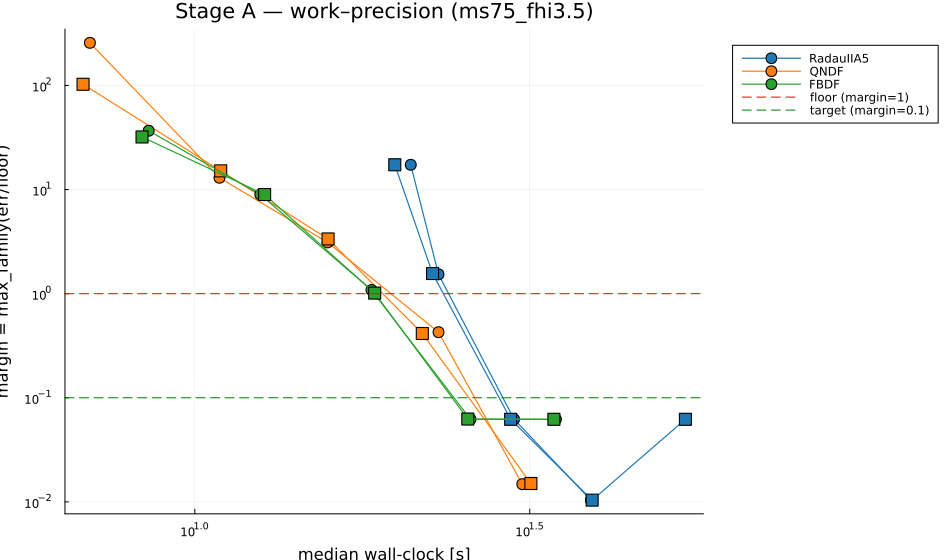

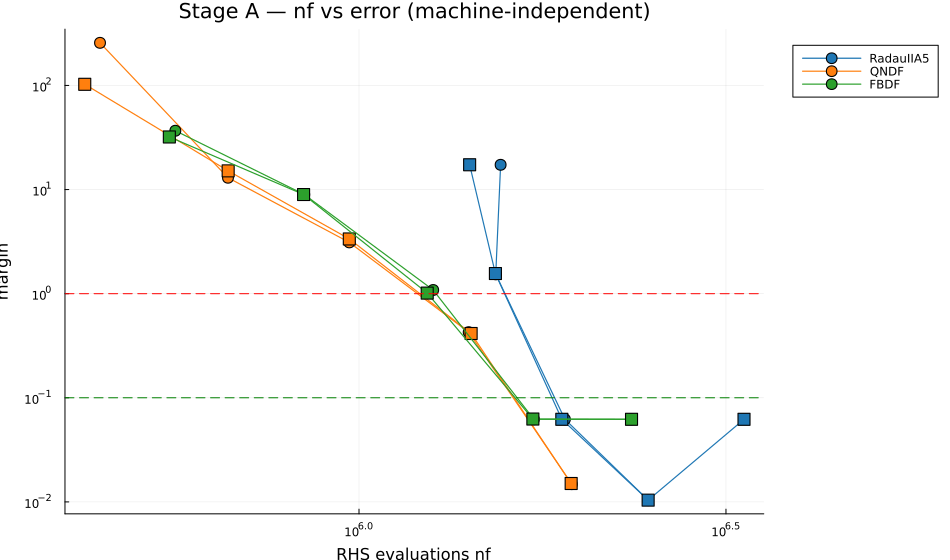

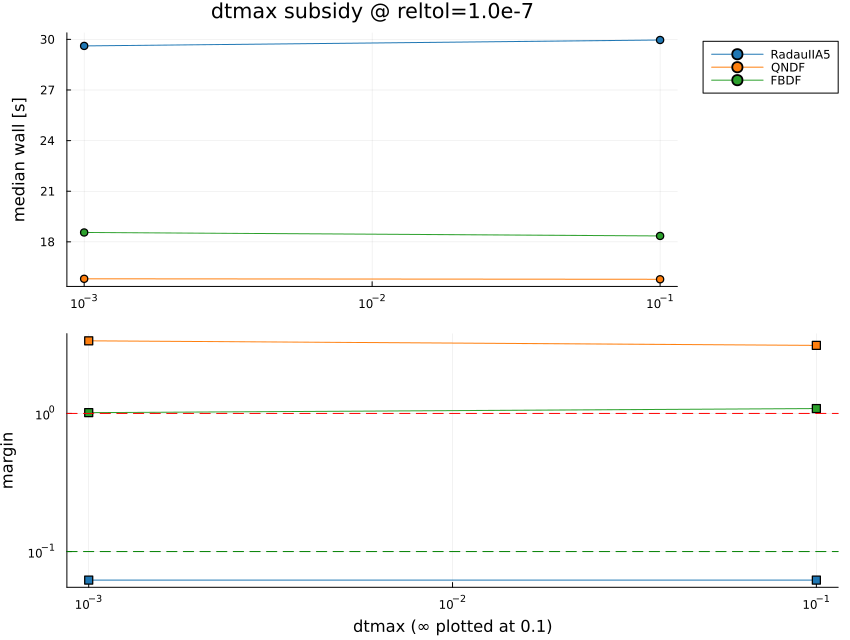


Cheapest PASSING configs (margin ≤ 0.1):


10×7 DataFrame
 Row │ solver     reltol   dtmax    wall_med  nf       margin     state_relerr 
     │ String     Float64  Float64  Float64   Int64    Float64    Float64      
─────┼─────────────────────────────────────────────────────────────────────────
   1 │ FBDF        1.0e-8    0.001   25.5556  1725515  0.0625203   0.000435052
   2 │ FBDF        1.0e-8  Inf       25.789   1730765  0.0621851   0.000151392
   3 │ RadauIIA5   1.0e-7    0.001   29.6122  1889465  0.0621762   8.32053e-5
   4 │ RadauIIA5   1.0e-7  Inf       29.9626  1907731  0.0621728   7.64554e-5
   5 │ QNDF        1.0e-9  Inf       30.8208  1949417  0.0148067   3.30443e-5
   6 │ QNDF        1.0e-9    0.001   31.745   1945713  0.0150321   3.35467e-5
   7 │ FBDF        1.0e-9    0.001   34.3561  2351417  0.06218     8.84221e-5
   8 │ FBDF        1.0e-9  Inf       34.595   2351664  0.0621828   9.38771e-5
   9 │ RadauIIA9   1.0e-9    0.001   37.9927  2554822  0.0873052   0.00019465
  10 │ RadauIIA5   1.0e-8  Inf       39.0

In [12]:
using Plots
SCOLOR = Dict(zip(SOLVER_ORDER, palette(:tab10)[1:length(SOLVER_ORDER)]))
DTMARK = Dict(Inf => :circle, 2e-2 => :utriangle, 5e-3 => :diamond, 1e-3 => :rect)
_dtlab(d) = isfinite(d) ? "dtmax=$(d)" : "dtmax=∞"

okA = filter(r -> r.ok && isfinite(r.margin), RESULTS_A)

# (1) work-precision: margin vs wall
p1 = plot(; xscale=:log10, yscale=:log10, xlabel="median wall-clock [s]",
          ylabel="margin = max_family(err/floor)", title="Stage A — work–precision ($(PRIMARY_CASE))",
          legend=:outertopright, size=(950, 560))
for s in SOLVER_ORDER, d in DTMAXES
    sub = sort(filter(r -> r.solver == s && r.dtmax == d, okA), :reltol; rev=true)
    isempty(sub) && continue
    plot!(p1, sub.wall_med, sub.margin; color=SCOLOR[s], marker=DTMARK[d], ms=6, lw=1.2,
          label = d == DTMAXES[1] ? s : "")
end
hline!(p1, [1.0];  ls=:dash, c=:red,   label="floor (margin=1)")
hline!(p1, [0.1];  ls=:dash, c=:green, label="target (margin=0.1)")
display(p1); savefig(p1, joinpath(BENCH_DIR, "stageA_workprecision_wall.png"))

# (2) machine-independent: margin vs nf
p2 = plot(; xscale=:log10, yscale=:log10, xlabel="RHS evaluations nf",
          ylabel="margin", title="Stage A — nf vs error (machine-independent)",
          legend=:outertopright, size=(950, 560))
for s in SOLVER_ORDER, d in DTMAXES
    sub = sort(filter(r -> r.solver == s && r.dtmax == d, okA), :reltol; rev=true)
    isempty(sub) && continue
    plot!(p2, sub.nf, sub.margin; color=SCOLOR[s], marker=DTMARK[d], ms=6, lw=1.2,
          label = d == DTMAXES[1] ? s : "")
end
hline!(p2, [1.0]; ls=:dash, c=:red, label=""); hline!(p2, [0.1]; ls=:dash, c=:green, label="")
display(p2); savefig(p2, joinpath(BENCH_DIR, "stageA_workprecision_nf.png"))

# (3) dtmax-subsidy slice at the middle tolerance: cost panel + accuracy panel
rt_mid = RELTOLS_EFF[cld(length(RELTOLS_EFF), 2)]
sub3 = filter(r -> r.reltol == rt_mid, okA)
p3a = plot(; xscale=:log10, ylabel="median wall [s]",
           title="dtmax subsidy @ reltol=$(rt_mid)", legend=:outertopright)
p3b = plot(; xscale=:log10, yscale=:log10, xlabel="dtmax (∞ plotted at 0.1)",
           ylabel="margin", legend=false)
for s in SOLVER_ORDER
    ss = sort(filter(r -> r.solver == s, sub3), :dtmax)
    isempty(ss) && continue
    x = [isfinite(d) ? d : 0.1 for d in ss.dtmax]
    plot!(p3a, x, ss.wall_med; color=SCOLOR[s], marker=:circle, label=s)
    plot!(p3b, x, ss.margin;   color=SCOLOR[s], marker=:rect,   label="")
end
hline!(p3b, [1.0]; ls=:dash, c=:red, label=""); hline!(p3b, [0.1]; ls=:dash, c=:green, label="")
p3 = plot(p3a, p3b; layout=(2,1), size=(850, 640))
display(p3); savefig(p3, joinpath(BENCH_DIR, "stageA_dtmax_subsidy.png"))

# (4) cheapest passing configs
passing = sort(filter(r -> r.margin <= 0.1, okA), :wall_med)
println("\nCheapest PASSING configs (margin ≤ 0.1):")
isempty(passing) ? println("  none — loosen target, check the floor, or extend RELTOLS") :
    show(first(select(passing, :solver,:reltol,:dtmax,:wall_med,:nf,:margin,:state_relerr), 10),
         allrows=true); println()

### Shortlisting the finalists

Auto-suggestion = the cheapest passing config of each of the two cheapest-passing *solvers*,
plus one tolerance notch tighter as the safety bracket (the brief's "2–3 tolerances at the
knee"). **This is a suggestion, not a decision** — inspect the work–precision plots first
(particularly: is the cheap config sitting right *at* the knee, where a slightly harder case in
Stage B could push it over?), then edit `FINALISTS` by hand if the curves say otherwise.

In [13]:
function suggest_finalists(df; target = 0.1)
    pass = sort(filter(r -> r.ok && r.margin <= target, df), :wall_med)
    isempty(pass) && error("No passing configs — inspect Stage A before proceeding.")
    out = NamedTuple[]
    for s in unique(pass.solver)
        length(out) >= 2 && break
        best = first(filter(r -> r.solver == s, pass))
        push!(out, (solver = best.solver, reltol = best.reltol, dtmax = best.dtmax))
        # one notch tighter at the same dtmax, if it exists
        tighter = filter(r -> r.solver == s && r.dtmax == best.dtmax &&
                              r.reltol < best.reltol && r.ok, df)
        if !isempty(tighter)
            t = sort(tighter, :reltol; rev = true)[1, :]
            push!(out, (solver = t.solver, reltol = t.reltol, dtmax = t.dtmax))
        end
    end
    out
end

FINALISTS = suggest_finalists(RESULTS_A)
# FINALISTS = [(solver="Rodas5P", reltol=1e-7, dtmax=Inf), ...]   # <- manual override here
println("Finalist configs for Stage B:")
foreach(f -> println("   ", f), FINALISTS)

Finalist configs for Stage B:

   (solver = "FBDF", reltol = 1.0e-8, dtmax = 0.001)
   (solver = "FBDF", reltol = 1.0e-9, dtmax = 0.001)


In [14]:
# [override] exactly the two configs to extend across all 7 Stage-B cases.
FINALISTS = [
    (solver = "RadauIIA5", reltol = 1e-8,  dtmax = 1e-3),
    (solver = "QNDF",      reltol = 1e-10, dtmax = 1e-3),
]
println("EXTEND FINALISTS:"); foreach(f -> println("   ", f), FINALISTS)


EXTEND FINALISTS:
   (solver = "RadauIIA5", reltol = 1.0e-8, dtmax = 0.001)
   (solver = "QNDF", reltol = 1.0e-10, dtmax = 0.001)


### Stage B — robustness across the 6 multisine cases

The finalist configs run on **every case**: both amplitude caps × the three `f_hi` bandwidths.
Each case is judged against **its own** interpolation floor (the floor is trajectory-dependent —
the 50 %-cap rows spend more time in deep stick, the 75 %-cap rows in hard slip, and their
stick–slip transition densities differ).

What would disqualify a finalist here:

- a passing margin on the primary case that **fails on the gentle `f_hi = 1.0` rows** — long
  stick dwells are where the bristle boundary layer is stiffest relative to the dynamics, and
  where A-stable-but-not-L-stable methods can ring;
- **wall-clock blow-up on any case** (step-size thrashing through stick–slip), even with
  acceptable error — the production sweep multiplies every pathology by ~1,485;
- a `state_relerr` spike (e.g. in the `bristle` group) while label margins stay green — a sign
  the labels are being saved by averaging, not accuracy.

Optional (`RUN_VARIANTS = true`): the brief's μ = 0.6 and χ = 0.0 variants on the primary case —
each needs its own reference, so they're off by default.

In [15]:
function ensure_reference!(case::BenchCase; mu = MU_BENCH, chi = CHI_BENCH, fm = FM_BENCH)
    haskey(REFS, case.name) && return
    refsol, wall = reference_for(case; mu = mu, chi = chi, fm = fm)
    ctx = case_context(case; mu = mu)
    lab = labels_of(refsol, ctx; chi = chi, friction_model = fm)
    n4  = length(refsol.t)
    mid = 2:2:(n4 - 1)
    midm = mid[findall(i -> refsol.t[i] >= T_EXCLUDE, mid)]
    interp_err(A) = rms(A[:, midm] .- 0.5 .* (A[:, midm .- 1] .+ A[:, midm .+ 1]))
    REFS[case.name] = refsol;  REF_LABELS[case.name] = lab
    FLOORS[case.name] = (; F = interp_err(vcat(lab.Fxs, lab.Fys)),
                           Mz = interp_err(lab.Mzs), Msat = interp_err(lab.Msat))
    f = FLOORS[case.name]
    @printf("%-14s  floor  F=%.3e  Mz=%.3e  Msat=%.3e   (ref wall %.0fs)\n",
            case.name, f.F, f.Mz, f.Msat, wall)
end

REF_CASES = REF_CASE_NAMES === nothing ? CASES : [CASE_BY_NAME[n] for n in REF_CASE_NAMES]
for case in REF_CASES;  ensure_reference!(case);  end

In [16]:
const STAGEB_PATH = joinpath(BENCH_DIR, "stageB_results.arrow")
RESULTS_B = _load_results(STAGEB_PATH)
# [extend] removed destructive filter to PRESERVE prior Stage B rows
# [extend] removed destructive filter to PRESERVE prior Stage B rows
for f in FINALISTS, case in CASES
    _done(RESULTS_B, case.name, f.solver, f.reltol, f.dtmax) && continue
    ensure_reference!(case)
    @info "Stage B" case=case.name solver=f.solver reltol=f.reltol dtmax=f.dtmax
    row = run_config(case, f.solver, f.reltol, f.dtmax; stage = "B")
    push!(RESULTS_B, row); _save!(RESULTS_B, STAGEB_PATH)
    @printf("   wall=%7.1fs  margin=%9.3g  state=%.2e (%s)\n",
            row.wall_med, row.margin, row.state_relerr, row.state_worst)
end

if RUN_VARIANTS
    case = CASE_BY_NAME[PRIMARY_CASE]
    for (mu, chi, tag) in ((0.6, CHI_BENCH, "mu0.6"), (MU_BENCH, 0.0, "chi0.0"))
        # variant reference + floor, keyed separately
        refsol, _ = reference_for(case; mu = mu, chi = chi)
        ctx = case_context(case; mu = mu)
        lab = labels_of(refsol, ctx; chi = chi)
        n4 = length(refsol.t); mid = 2:2:(n4-1)
        midm = mid[findall(i -> refsol.t[i] >= T_EXCLUDE, mid)]
        ie(A) = rms(A[:, midm] .- 0.5 .* (A[:, midm .- 1] .+ A[:, midm .+ 1]))
        vname = "$(case.name)+$tag"
        REFS[vname] = refsol; REF_LABELS[vname] = lab
        FLOORS[vname] = (; F = ie(vcat(lab.Fxs, lab.Fys)), Mz = ie(lab.Mzs), Msat = ie(lab.Msat))
        vcase = BenchCase(vname, case.file, case.profile, case.combo_idx, case.f_hi,
                          case.cap_tag, case.ref, case.cfg)
        for f in FINALISTS
            _done(RESULTS_B, vname, f.solver, f.reltol, f.dtmax) && continue
            row = run_config(vcase, f.solver, f.reltol, f.dtmax; stage = "B", mu = mu, chi = chi)
            push!(RESULTS_B, row); _save!(RESULTS_B, STAGEB_PATH)
        end
    end
end
println("Stage B complete: $(nrow(RESULTS_B)) rows")

┌ Info: Stage B
│   case = "ms75_fhi1.0"
│   solver = "RadauIIA5"
│   reltol = 1.0e-8
└   dtmax = 0.001


   wall=   41.6s  margin=   0.0139  state=2.94e-05 (bristle)


┌ Info: Stage B
│   case = "ms75_fhi2.5"
│   solver = "RadauIIA5"
│   reltol = 1.0e-8
└   dtmax = 0.001


   wall=   44.8s  margin=   0.0209  state=4.67e-05 (bristle)


┌ Info: Stage B
│   case = "ms75_fhi3.5"
│   solver = "RadauIIA5"
│   reltol = 1.0e-8
└   dtmax = 0.001


...

   wall=   39.9s  margin=    0.011  state=2.82e-05 (bristle_rot)


┌ Info: Stage B
│   case = "ms50_fhi3.5"
│   solver = "QNDF"
│   reltol = 1.0e-10
└   dtmax = 0.001


   wall=   41.7s  margin=  0.00321  state=8.86e-06 (bristle_rot)


┌ Info: Stage B
│   case = "spiral_iso_u0.95"
│   solver = "QNDF"
│   reltol = 1.0e-10
└   dtmax = 0.001


   wall=    9.5s  margin= 0.000682  state=1.22e-06 (bristle_rot)
Stage B complete: 42 rows
